# Pyomo.DAE Example: Temperature Control Lab

This page is [adapted from our process control class](https://github.com/ndcbe/controls/blob/main/notebooks/6/Simulation-and-Open-Loop-Optimal-Control.ipynb) at Notre Dame; it was developed by Prof. Jeff Kantor.

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 6 rewritten and 2 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

## Learning Objectives

* Review syntax for Pyomo.DAE
* See how an optimization problem with zero degrees of freedom is a simulation problem
* Practice using the [units](https://pyomo.readthedocs.io/en/stable/advanced_topics/units_container.html)
  feature in Pyomo
* See why a units-correct `Pyomo.dae` model must be checked **before**
  discretization (see [](./units_and_pyomo_dae.md))

## Install Packages and Load Modules

In [1]:
# Install Pyomo and solvers for Google Colab
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

# import Pyomo library
import pyomo.environ as pyo
import pyomo.dae as dae
import matplotlib.pyplot as plt
from pyomo.environ import units
from pyomo.util.check_units import assert_units_consistent

## Temperature Control Lab Dynamic Model

The [temperature control lab](http://apmonitor.com/pdc/index.php/Main/ArduinoTemperatureControl) is an Arduino-based hands-on experiment for teaching dynamic modeling and process control developed by Prof. John Hedengren. At Notre Dame, we restructured our core [undergraduate process control class](https://ndcbe.github.io/controls/Readme.html) around six hands-on laboratory assignments with the TCLab.

The TCLab board contains two heater plus temperature sensor assemblies. Using Python (or MATLAB), students can independently manipulate the electrical power to the heaters and measure the temperatures.

For simplicity, we will develop a mathematical single heater and temperature sensor assembly. However, this workshop example also supports modeling both assemblies.

![TCLab schematic](https://raw.githubusercontent.com/ndcbe/optimization/main/media/tclab_schematic2.jpg)

We will define two **states**:
* $T_{H,1}$ is the temperature of the heater/fin assembly (°C)
* $T_{S,1}$ is the temperature of the sensor (°C)

Assumptions:
* The two bodies are uniform temperature, i.e., we are neglecting any temperature gradients in the fin.
* The sensor exchanges heat only with the heater, and heat transfer to the surroundings is dominated by the heat sink attached to the heater.
* Heat capacities $C_p$ are constant.
* Radiative heat transfer is negligible.

We define the **manipulated variable**:
* $u_1$ is the power sent to the heater (% of max)

This motivates the following model:

$$
\begin{align}
C^H_p\frac{dT_{H,1}}{dt} & = U_a(T_{amb} - T_{H,1}) + U_b(T_{S,1} - T_{H,1}) + \alpha P_1u_1\\
C^S_p\frac{dT_{S,1}}{dt} & = U_b(T_{H,1} - T_{S,1}) 
\end{align}
$$

The model has the following **unknown parameters**:
* $C^H_p$ is the heat capacity of the heater/fin assembly (J / °C)
* $C^S_p$ is the heat capacity of the sensor (J / °C)
* $U_a$ is the heat transfer coefficient from the heater/fin to ambient (W / °C)
* $U_b$ is the heat transfer coefficient from the heater/fin to the sensor (W / °C)

And the following **known parameters**:
* $\alpha P_1$ are constants for the TCLab (W / %)
* $T_{amb}$ is the ambient temperature (°C)

Let's start by defining some model coefficients:

In [2]:
# parameters
# alpha * P converts heater command (%) to power (W), so alpha*P must be W / %.
# Percent is dimensionless, so W / % is just W.
alpha = 0.00016 * units.W  # W per (unit of P * percent of u1)
P = 200  # dimensionless scale factor for the heater
Ua = (
    0.050 * units.W / units.kelvin
)  # heat transfer coefficient from heater to environment
CpH = 2.2 * units.J / units.kelvin  # heat capacity of the heater (J/deg C)
CpS = 1.9 * units.J / units.kelvin  # heat capacity of the sensor (J/deg C)
Ub = 0.021 * units.W / units.kelvin  # heat transfer coefficient from heater to sensor
Tamb_C = 21.0  # ambient temperature in deg C
Tamb = units.convert_temp_C_to_K(Tamb_C) * units.kelvin  # ambient temperature

## Simulate a Step Test (ramp)

We will start by **simulating** our TCLab model. In other words, we will solve the following optimization problem with zero degrees of freedom:

\begin{align*}
\max{}~~ & 0 \\
\mathrm{s.t.}~~ & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t) \\
 & C_p^S \frac{dT_S}{dt} = - U_b (T_S - T_H) \\
 & T_H(t_0) = T_{amb} \\
 & T_S(t_0) = T_{amb} \\
 & u(t) = u_{ramp} = 50\%, \quad \forall t \in [t_0, t_f]
\end{align*}

Here "s.t." means "subject to", i.e., the constraints.

Units are consistent (continuous model, before discretization).


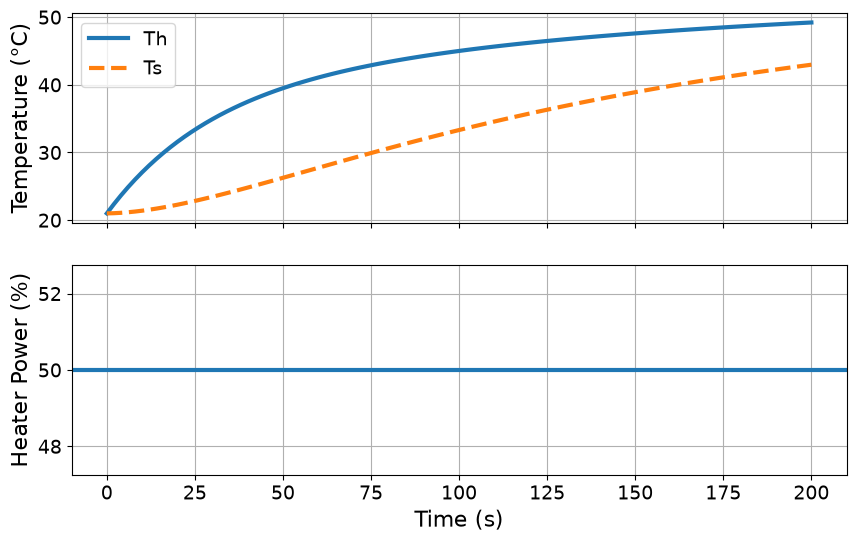

In [3]:
# Final time [seconds].
#
# Why no units here? A ContinuousSet cannot carry units. This is Pyomo issue
# #1790, still open: https://github.com/Pyomo/pyomo/issues/1790
# It is also the reason we must check units BEFORE discretizing -- see the
# section below and ./units_and_pyomo_dae.md
tf = 200

# control input [%]
u = 50.0

# Create a Pyomo model
m = pyo.ConcreteModel("TCLab Heater/Sensor")

# Define time domain
m.t = dae.ContinuousSet(bounds=(0, tf))

# Define the state variables as a function of time
m.Th = pyo.Var(m.t, units=units.kelvin)
m.Ts = pyo.Var(m.t, units=units.kelvin)

# Define the derivatives of the state variables.
#
# DerivativeVar defaults to DIMENSIONLESS -- it does not inherit units from the
# state variable. Here m.t is time in seconds, so dT/dt is K/s. Say it explicitly.
m.dTh = dae.DerivativeVar(m.Th, units=units.kelvin / units.s)
m.dTs = dae.DerivativeVar(m.Ts, units=units.kelvin / units.s)


# Define the first differential equation
def heater1(m, t):
    return (
        CpH * m.dTh[t]
        == Ua * (Tamb - m.Th[t]) + Ub * (m.Ts[t] - m.Th[t]) + alpha * P * u
    )


m.heater1_con = pyo.Constraint(m.t, rule=heater1)


# Define the second differential equation
def sensor1(m, t):
    return CpS * m.dTs[t] == Ub * (m.Th[t] - m.Ts[t])


m.sensor1_con = pyo.Constraint(m.t, rule=sensor1)

# Set the initial conditions
m.Th[0].fix(Tamb)
m.Ts[0].fix(Tamb)

# Check dimensional consistency NOW, while the model is still continuous.
# After discretization this same call raises InconsistentUnitsError -- see below.
assert_units_consistent(m)
print("Units are consistent (continuous model, before discretization).")

# Apply a finite difference formula to numerically integrate the differential equations
pyo.TransformationFactory("dae.finite_difference").apply_to(m, nfe=100, wrt=m.t)

# Call our nonlinear optimization/equation solver, Ipopt
results = pyo.SolverFactory("ipopt").solve(m)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

# Plot the results
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot 1: Temperature
ax[0].plot(m.t, [units.convert_temp_K_to_C(m.Th[t]()) for t in m.t], label="Th")
ax[0].plot(
    m.t, [units.convert_temp_K_to_C(m.Ts[t]()) for t in m.t], label="Ts", linestyle="--"
)
ax[0].legend()
ax[0].set_ylabel("Temperature (°C)")
ax[0].grid()

# Plot 2: Heater Power
ax[1].axhline(u, label="Power")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Heater Power (%)")
ax[1].grid()
plt.show()

### Why the units check comes *before* `TransformationFactory`

The cell above called `assert_units_consistent(m)` immediately before discretizing.
The order is not cosmetic.

```{warning}
Run the same check *after* `TransformationFactory("dae.finite_difference")` and it
**fails**, on a model that is dimensionally correct:

    InconsistentUnitsError: Error in units found in expression:
      dTh[2.0] - 0.5*(Th[2.0] - Th[0]): kelvin / second not compatible with kelvin.

`dae.collocation` fails the same way. So does every other model in this section whose
time domain is measured in seconds.
```

Here is what happened. A backward difference for $\frac{dT_H}{dt}$ at time $t_i$ is

$$
\dot{T}_{H,i} \approx \frac{T_{H,i} - T_{H,i-1}}{\Delta t},
$$

and Pyomo writes it out with $1/\Delta t$ already evaluated to a number:

```text
dTh[2.0] == 0.5*(Th[2.0] - Th[0])
```

That `0.5` **is** $1/\Delta t$, and it *should* carry units of $\mathrm{s}^{-1}$.
It does not. A `ContinuousSet` stores plain Python floats and cannot hold units, which
is exactly why `tf = 200` above has its units only in a comment. Pyomo therefore reads
the right-hand side as a temperature and the left-hand side as a temperature rate,
and reports -- correctly, given what it can see -- that they disagree.

This is [Pyomo issue #1790](https://github.com/Pyomo/pyomo/issues/1790), **still
open**. Nothing is wrong with our model and nothing is wrong with the finite-difference
arithmetic; the units container simply has nowhere to record what the time domain is
measured in.

The practical rule is short:

> **Declare units on everything, then `assert_units_consistent` at the end of your
> model-building function, before any discretization.**

You give up nothing by checking early. The discretization equations are generated by
Pyomo, not written by you, so they are not where your modeling errors hide. Checking
the continuous model checks every equation you actually typed.

Run the cell below to see the failure for yourself.


In [4]:
# Reproduce the failure. The model `m` above has already been discretized, so
# asserting on it now raises -- even though the SAME model passed the check moments
# before `TransformationFactory` was applied.

try:
    assert_units_consistent(m)
    print("Units are consistent -- unexpected!")
except Exception as e:
    print(type(e).__name__)
    print(e)

ERROR: Units problem with expression dTh[2.0] - 0.5*(Th[2.0] - Th[0])


ERROR: Error in units when checking dTh_disc_eq[2.0]


InconsistentUnitsError
Error in units found in expression: dTh[2.0] - 0.5*(Th[2.0] - Th[0]): kelvin / second not compatible with kelvin.


```{note}
Two things `assert_units_consistent` does **not** check: `Var` bounds and values passed
to `.fix()`. Both `m.u = pyo.Var(m.t, bounds=(0, 100))` and `m.Th[0].fix(Tamb)` would
pass even if the bare numbers were in the wrong units. Units are a strong check on your
*equations* and no check at all on your *numbers*.

The related trap in this notebook: `m.dTh = dae.DerivativeVar(m.Th)` -- with no
`units=` -- defaults to **dimensionless**, not to K/s. `DerivativeVar` never infers
units from its state variable. Written that way, `assert_units_consistent` fails on the
*continuous* model, before any discretization, with

    joule / kelvin not compatible with watt

because `CpH * m.dTh[t]` collapses to J/K instead of J/s. Compare that with the
post-discretization message in the warning above (`kelvin / second not compatible with
kelvin`): the two failures read quite differently, which is how you tell a **missing
declaration** from **issue #1790**.

See [](./units_and_pyomo_dae.md) for the whole picture, including the one modeling
choice that sidesteps issue #1790 (scaling time onto a dimensionless interval, as in
[](./PyomoDAE_car.ipynb)).
```


The code below to access and print results from the Pyomo model:


In [5]:
for i, t in enumerate(m.t):
    # Only print every 10 timesteps
    if i % 10 == 0:
        print(
            "Th=",
            round(pyo.value(m.Th[t]), 2),
            "K and Ts=",
            round(pyo.value(m.Ts[t]), 2),
            "K at time",
            round(t, 2),
            "seconds.",
        )

Th= 294.15 K and Ts= 294.15 K at time 0 seconds.
Th= 304.71 K and Ts= 295.43 K at time 20.0 seconds.
Th= 310.66 K and Ts= 297.97 K at time 40.0 seconds.
Th= 314.23 K and Ts= 300.88 K at time 60.0 seconds.
Th= 316.54 K and Ts= 303.78 K at time 80.0 seconds.
Th= 318.16 K and Ts= 306.47 K at time 100.0 seconds.
Th= 319.37 K and Ts= 308.91 K at time 120.0 seconds.
Th= 320.33 K and Ts= 311.07 K at time 140.0 seconds.
Th= 321.12 K and Ts= 312.98 K at time 160.0 seconds.
Th= 321.79 K and Ts= 314.66 K at time 180.0 seconds.
Th= 322.36 K and Ts= 316.12 K at time 200 seconds.


Uncomment and run the code below to see the details of the Pyomo model:

In [6]:
# m.pprint()

## Activity: Optimization by Trial-and-Error

Modify the code above to find the value for `u` that causes `Th` to reach 60 °C at the final time. In others words, we are using trial and error to solve the following optimization problem:

\begin{align*}
\min_{u_{ramp}} ~~ & ||~ T_{H}(t_f) - 60 ~||^2 \\
\mathrm{s.t.}~~ & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t) \\
 & C_p^S \frac{dT_S}{dt} = - U_b (T_S - T_H) \\
 & T_H(t_0) = T_{amb} \\
 & T_S(t_0) = T_{amb} \\
 & u(t) = u_{ramp}, \quad \forall t \in [t_0, t_f]
\end{align*}


## Feedforward Optimal Control

An optimal control policy minimizes the differences

$$
\begin{align*}
\min_{u} \int_{t_0}^{t_f} \|~SP(t) - T_H(t)~\|^2\,dt \\
\end{align*}
$$

subject to constraints

$$
\begin{align*}
C_p^H \frac{dT_H}{dt} & = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t)\\
C_p^S \frac{dT_S}{dt} & = - U_b (T_S - T_H)  \\
\\
\text{control limits}\qquad0 \leq u(t) & \leq 100.0
\\
\text{initial condition}\qquad T_H(t_0) & = T_{amb} \\
\text{initial condition}\qquad T_S(t_0) & = T_{amb}
\end{align*}
$$

This is different than our example above because we allow $u$ to have a unique value for each timestep.

Note that `pyomo.dae` has an `Integral` object to help with these situations.

ise units: K**2


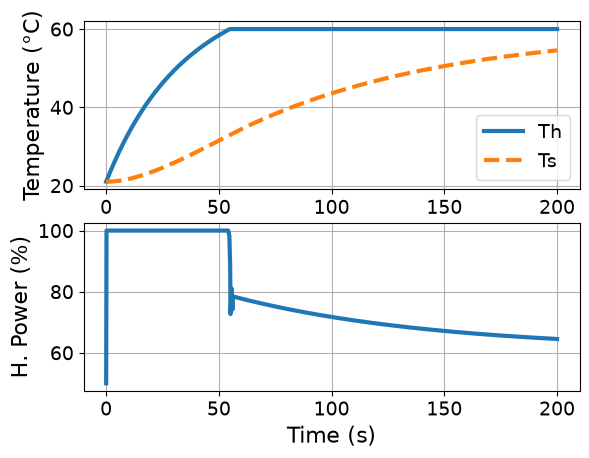

In [7]:
# Set point, deg C
SP = units.convert_temp_C_to_K(60.0) * units.kelvin

# Create a Pyomo model
m = pyo.ConcreteModel("TCLab Heater/Sensor")

# Define time domain
m.t = dae.ContinuousSet(bounds=(0, tf))

# Define the state variables as a function of time
m.Th = pyo.Var(m.t, units=units.kelvin)
m.Ts = pyo.Var(m.t, units=units.kelvin)

# Define the derivatives of the state variables (K/s -- state it explicitly)
m.dTh = dae.DerivativeVar(m.Th, units=units.kelvin / units.s)
m.dTs = dae.DerivativeVar(m.Ts, units=units.kelvin / units.s)

# Define the control variable (heater power, % of max) as a function of time.
# Percent is dimensionless; alpha * P carries the W / % conversion.
m.u = pyo.Var(m.t, bounds=(0, 100))


# Define the integral of the squared error
@m.Integral(m.t)
def ise(m, t):
    return (SP - m.Th[t]) ** 2


# Define the first differential equation
# Notice we are defining the equation using the decorator syntax
@m.Constraint(m.t)
def heater1(m, t):
    return (
        CpH * m.dTh[t]
        == Ua * (Tamb - m.Th[t]) + Ub * (m.Ts[t] - m.Th[t]) + alpha * P * m.u[t]
    )


# Define the second differential equation
@m.Constraint(m.t)
def sensor1(m, t):
    return CpS * m.dTs[t] == Ub * (m.Th[t] - m.Ts[t])


# Set the initial conditions
m.Th[0].fix(Tamb)
m.Ts[0].fix(Tamb)


# Define the objective function
@m.Objective(sense=pyo.minimize)
def objective(m):
    return m.ise


# Units, again checked on the continuous model before discretizing.
#
# Note that m.ise comes out in K**2, not K**2 * s. pyomo.dae builds the Integral
# as a weighted sum whose quadrature weights are dimensionless -- the same
# consequence of issue #1790. The objective is still internally consistent, so
# the check passes.
assert_units_consistent(m)
print("ise units:", units.get_units(m.ise))

# Apply a collocation method to numerically integrate the differential equations
pyo.TransformationFactory("dae.collocation").apply_to(m, nfe=200, wrt=m.t)

# Call our nonlinear optimization/equation solver, Ipopt
results = pyo.SolverFactory("ipopt").solve(m)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)


# We are going to repeat plotting two more times,
# so let's define a function
def plot_results(m):
    """
    Plot results from Pyomo optimization

    Arguments:
    m: Pyomo model

    Returns:
    Nothing

    """

    # Plot the results
    fig, ax = plt.subplots(2, 1)

    ax[0].plot(m.t, [units.convert_temp_K_to_C(m.Th[t]()) for t in m.t], label="Th")
    ax[0].plot(
        m.t,
        [units.convert_temp_K_to_C(m.Ts[t]()) for t in m.t],
        label="Ts",
        linestyle="--",
    )
    ax[0].legend()
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Temperature (°C)")
    ax[0].grid()

    ax[1].plot(m.t, [m.u[t]() for t in m.t], label="u")
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("H. Power (%)")
    ax[1].grid()


plot_results(m)

## Controlling to a Reference Trajectory

Now let's consider optimizing the control input $u(t)$ to track a more sophisticated time-varying setpoint signal $SP(t)$.

Python function `r(t)` uses `numpy.interp` to compute values of the reference trajectory at any point in time.

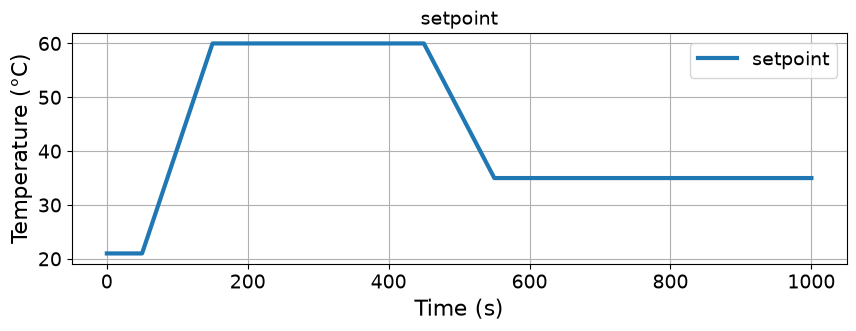

In [8]:
import numpy as np

# time grid
tf = 1000
dt = 2
n = round(tf / dt)
t_grid = np.linspace(0, tf, n + 1)


# setpoint/reference
def r(t):
    return np.interp(t, [0, 50, 150, 450, 550], [Tamb_C, Tamb_C, 60, 60, 35])


# plot function
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(t_grid, r(t_grid), label="setpoint")
ax.set_title("setpoint")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Time (s)")
ax.legend()
ax.grid(True)

Now let's solve the optimal control problem to find a control policy $u(t)$ for the interval $t_0 \leq t \leq t_f$ which causes the output $T_H(t)$ to track a desired setpoint or reference trajectory $SP(t)$.

\begin{align*}
\min_{u(t)} ~~ & \int_{t_0}^{t_f} \|~SP(t) - T_H(t)~\|^2\,dt \\
\mathrm{s.t.}~~ & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t) \\
 & C_p^S \frac{dT_S}{dt} = - U_b (T_S - T_H) \\
 & T_H(t_0) = T_{amb} \\
 & T_S(t_0) = T_{amb}
\end{align*}

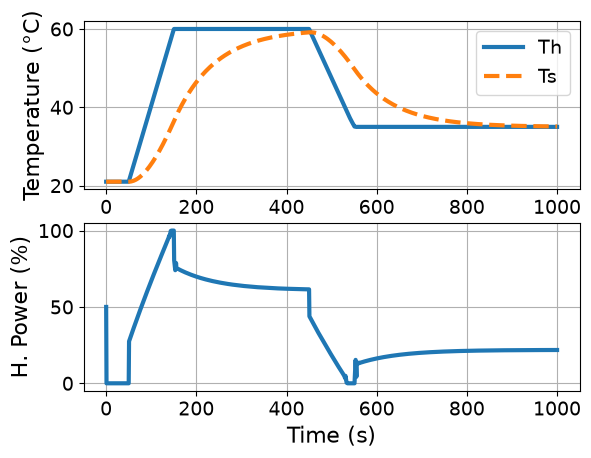

In [9]:
# Create a Pyomo model
m = pyo.ConcreteModel("TCLab Heater/Sensor")

# Define time domain
m.t = dae.ContinuousSet(bounds=(0, tf))

# Define the state variables as a function of time
m.Th = pyo.Var(m.t, units=units.kelvin)
m.Ts = pyo.Var(m.t, units=units.kelvin)

# Define the derivatives of the state variables (K/s -- state it explicitly)
m.dTh = dae.DerivativeVar(m.Th, units=units.kelvin / units.s)
m.dTs = dae.DerivativeVar(m.Ts, units=units.kelvin / units.s)

# Define the control variable (heater power) as a function of time
m.u = pyo.Var(m.t, bounds=(0, 100))


# Define the integral of the squared error
@m.Integral(m.t)
def ise(m, t):
    return (units.convert_temp_C_to_K(r(t)) * units.kelvin - m.Th[t]) ** 2


# Define the first differential equation
@m.Constraint(m.t)
def heater1(m, t):
    return (
        CpH * m.dTh[t]
        == Ua * (Tamb - m.Th[t]) + Ub * (m.Ts[t] - m.Th[t]) + alpha * P * m.u[t]
    )


# Define the second differential equation
@m.Constraint(m.t)
def sensor1(m, t):
    return CpS * m.dTs[t] == Ub * (m.Th[t] - m.Ts[t])


# Fix the initial conditions
m.Th[0].fix(Tamb)
m.Ts[0].fix(Tamb)


# Define the objective function
@m.Objective(sense=pyo.minimize)
def objective(m):
    return m.ise


# Units, again checked on the continuous model before discretizing.
assert_units_consistent(m)

# Apply a collocation method to numerically integrate the differential equations
pyo.TransformationFactory("dae.collocation").apply_to(m, nfe=200, wrt=m.t)

# Call our nonlinear optimization/equation solver, Ipopt
results = pyo.SolverFactory("ipopt").solve(m)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

plot_results(m)

## Take Away Messages

1. Pyomo is a great environment to formulate and solve optimization problems.
2. Predictive models are critical for intelligent decision making.
